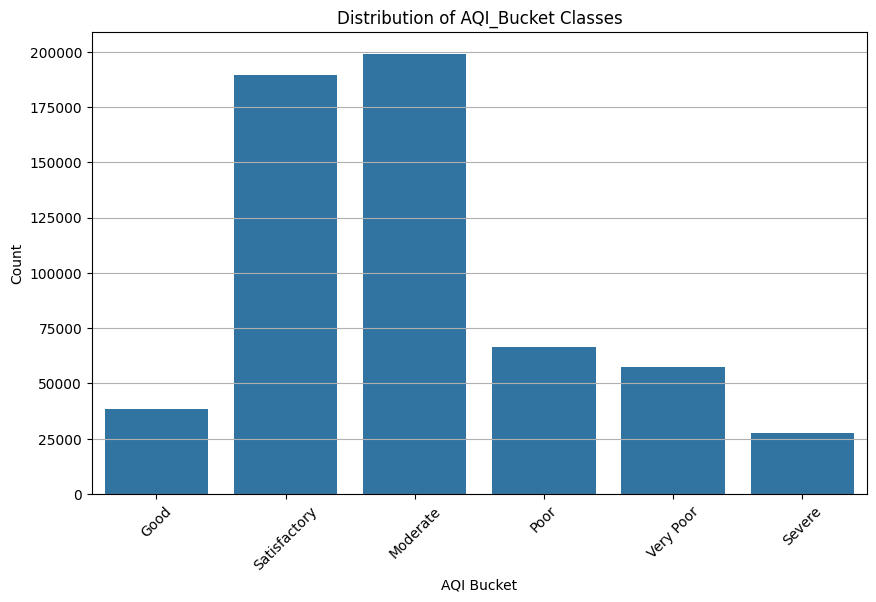

In [1]:
#Data's Histogram
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('air_quality_feature.csv')  # Ensure correct path

# Create count plot for AQI_Bucket
plt.figure(figsize=(10, 6))
sns.countplot(x='AQI_Bucket', data=df, order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe'])
plt.title('Distribution of AQI_Bucket Classes')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

k=1, Accuracy=0.8528
k=2, Accuracy=0.8170
k=3, Accuracy=0.8282
k=4, Accuracy=0.7982
k=5, Accuracy=0.8057
k=6, Accuracy=0.7843
k=7, Accuracy=0.7890
k=8, Accuracy=0.7721
k=9, Accuracy=0.7783
k=10, Accuracy=0.7642
k=11, Accuracy=0.7675
k=12, Accuracy=0.7556
k=13, Accuracy=0.7598
k=14, Accuracy=0.7482
k=15, Accuracy=0.7526
k=16, Accuracy=0.7429
k=17, Accuracy=0.7460
k=18, Accuracy=0.7383
k=19, Accuracy=0.7412
k=20, Accuracy=0.7328


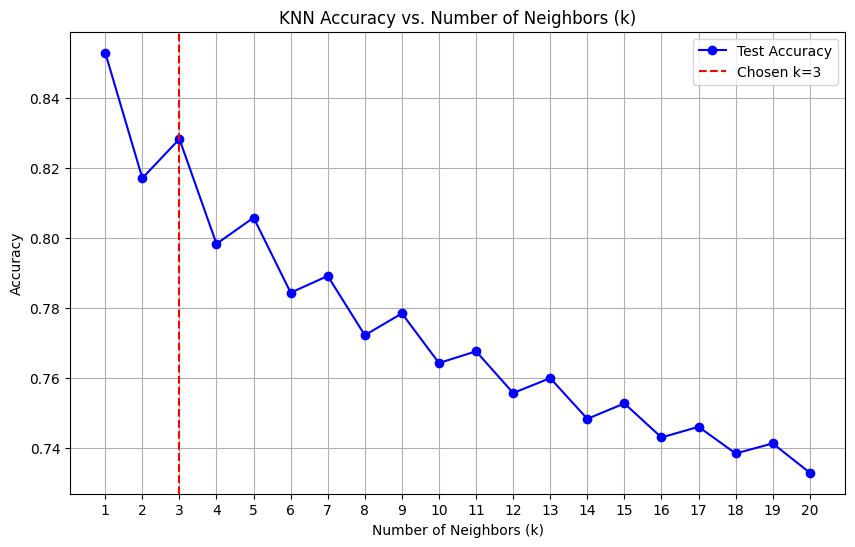

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Assuming your preprocessing steps are already done
# Load dataset (use your correct path)
df = pd.read_csv('air_quality_feature.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
df['Weekday'] = label_encoder.fit_transform(df['Weekday'])
df['City'] = label_encoder.fit_transform(df['City'])
df['AQI_Bucket'] = label_encoder.fit_transform(df['AQI_Bucket'])

# Numerical columns for IQR
numerical_columns = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
                     'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
                     'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
                     'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Apply IQR to each numerical column
for col in numerical_columns:
    df = remove_outliers(df, col)

# Features and target
features = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
            'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
            'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']
X = df[features]
y = df['AQI_Bucket']

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection (top 20 features)
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Lists to store accuracy for different k values
k_values = range(1, 21)  # Testing k from 1 to 20
accuracies = []

# Train KNN for each k and compute accuracy
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"k={k}, Accuracy={accuracy:.4f}")

# Plot the accuracy vs. k graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', label='Test Accuracy')
plt.axvline(x=3, color='r', linestyle='--', label='Chosen k=3')  # Highlight k=3
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.savefig('knn_accuracy_vs_k.png')  # Save the plot
plt.show()